**Plotting in Python with matplotlib**
Andrea Rachetta, Master@IBM - andrea.rachetta@{hs-hannover, rwth-aachen}.de / based on Marco Chierici & Giuseppe Jurman work @UniTN

Apr 2026 / Apr 26, 2023

This notebook is from the https://github.com/gigibot-tech/data-visualization-storytelling-hsh/tree/main


**Common Jupyter notebook shortcuts**

- Create an empty code cell above the selected cell: ESC + A
- Create an empty code cell below the selected cell: ESC + B
- Change selected cell type from code to text (markdown): ESC + M
- Change selected cell type from text to code: ESC + Y
- Delete selected cell: ESC + DD (not a typo: two times D)
- Copy selected cell: ESC + C
- Paste selected cell below: ESC + V
- Execute current cell: SHIFT + ENTER

# Matplotlib(.pyplot)

Pyplot ist das *stateful interface* zu matplotlib.
This notebook is the practical entry point into Matplotlib (mlp), but with a stronger conceptual bridge between the examples.

It combines the quick-start feel of this video notebook with selected ideas from `Kopie_von_Intro_to_matplotlib.ipynb` (werden wir hin wechseln nach Chapter 0) and `matplotlib_fundamentals_explained.ipynb` (linspace).

**What you will learn**

1. The two main ways of creating plots: `pyplot` and the object-oriented (OO) interface
2. How to go from an empty `plt.plot()` call to plotting real x/y data
3. Why `fig, ax = plt.subplots()` is the default pattern we keep coming back to; ax "axes" heißt, fig für "figure" steht
4. How `np.linspace()` helps create smooth lines and well-spaced axes
4.1 The most common plot types with NumPy arrays and pandas data
5. How to customize labels, legends, ticks, limits, styles, and colors
6. How to save plots and where to go next afterwards

A short roadmap to the follow-up notebooks is included at the end.


**Characteristics**

Matplotlib is an excellent 2D and 3D graphics library for generating scientific figures. Some of the many advantages of this library include:

* Easy to get started
* Support for $\LaTeX$ formatted labels and texts
* Great control of every element in a figure, including figure size and DPI.
* High-quality output in many formats, including PNG, PDF, SVG, EPS, and PGF.
* GUI for interactively exploring figures *and* support for headless generation of figure files (useful for batch jobs).

One of the key features of matplotlib that I would like to emphasize, and that I think makes matplotlib highly suitable for generating figures for scientific publications is that all aspects of the figure can be controlled *programmatically*. This is important for reproducibility and convenient when one needs to regenerate the figure with updated data or change its appearance.

More information at the Matplotlib web page: http://matplotlib.org/



### Kick off

To load matplotlib, we use the following import convention:

In [94]:
!pip3 install matplotlib
#in einer neuen umgebung (z.B. Jupyter Labs, Kaggle), weil in Google Colab oder 
#auf deinem Rechner ist es schon vorinstalliert

19920.49s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip


In [95]:
import matplotlib as mlp
import matplotlib.pyplot as plt #API interface , pyplot

Since we are in a Jupyter notebook, we also execute the following statement to output plots directly in the Jupyter notebook:

In [96]:
# %matplotlib inline
# This magic command (when uncommented) tells Jupyter to:
# 1. Display plots directly in the notebook (embedded as static images)
# 2. Close figures automatically after displaying them
# 3. Use the 'inline' backend instead of interactive backends
#
# However, modern Jupyter (JupyterLab, VS Code) displays plots automatically
# even WITHOUT this magic, so it's often not needed anymore.
#
# Other backends you might see:
# - %matplotlib notebook  # interactive plots (older, deprecated)
# - %matplotlib widget    # interactive plots (modern, requires ipympl)
# - %matplotlib qt        # opens plots in separate Qt windows
#
# We keep it commented out because the default behavior works fine!

We also load the Python numerical library (NumPy: Numerical Python) and Pandas with their import convention:

In [97]:
import numpy as np
import pandas as pd

## Foundations


**What you will learn**

1. The two main ways of creating plots: `pyplot` and the object-oriented (OO) interface
2. How to go from an empty `plt.plot()` call to plotting real x/y data
3. Why `fig, ax = plt.subplots()` is the default pattern we keep coming back to; ax "axes" heißt, fig für "figure" steht
4. How `np.linspace()` helps create smooth lines and well-spaced axes
4.1 The most common plot types with NumPy arrays and pandas data
5. How to customize labels, legends, ticks, limits, styles, and colors
6. How to save plots and where to go next afterwards

A short roadmap to the follow-up notebooks is included at the end.

## pyplot & OO

Matplotlib gives us two closely related interfaces:

- `pyplot`: quick, state-based, great for getting started fast
- `OO` (object-oriented): explicit and more robust, especially when plots become more complex

We will start with `pyplot` because it makes the first examples very easy to read. Then we will switch to `fig, ax = plt.subplots()` and use that pattern as our default.

Start by importing `matplotlib.pyplot` and enabling inline output in the notebook.


Without a semicolon, Jupyter prints the Python return value of `plt.plot()`, which is usually a list of `Line2D` objects.

A trailing `;` suppresses that text output. It does **not** change the figure itself, it only keeps the notebook output cleaner.


[]

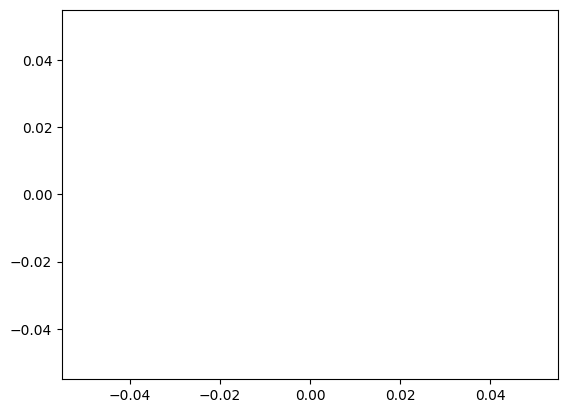

In [123]:
# Create a simple plot, without the semi-colon
plt.plot()        # draws → needs axes → needs figure → creates both

In [100]:
# You could use plt.show() if you want
#plt.plot()
plt.show()

[]

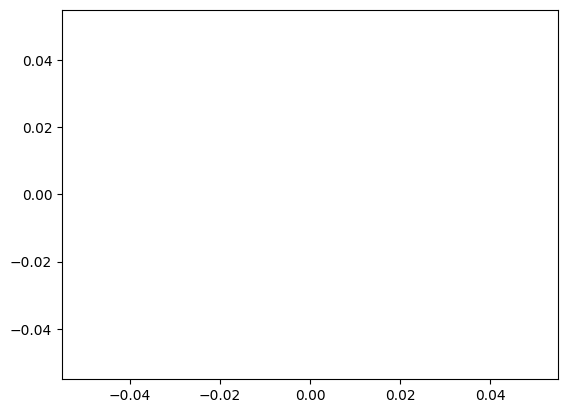

In [ ]:
#plt.show()   # nothing to show yet — no figure exists, this is essentially a no-op
plt.plot()   # creates an implicit figure, draws on it

# Jupyter notebooks automatically display matplotlib figures as output
# This happens even WITHOUT %matplotlib inline (which is commented out above)
# The figure is shown because Jupyter displays the last expression's result
# In a regular Python script, you would need plt.show() to display the plot

In [102]:
import matplotlib as mpl
mpl.rcParams['axes.xmargin']   # default 0.05
mpl.rcParams['axes.ymargin']   # default 0.05

0.05

In [103]:
#fig = plt.figure()  # explicitly creates a figure
plt.show()          # shows it (empty, since nothing was plotted)

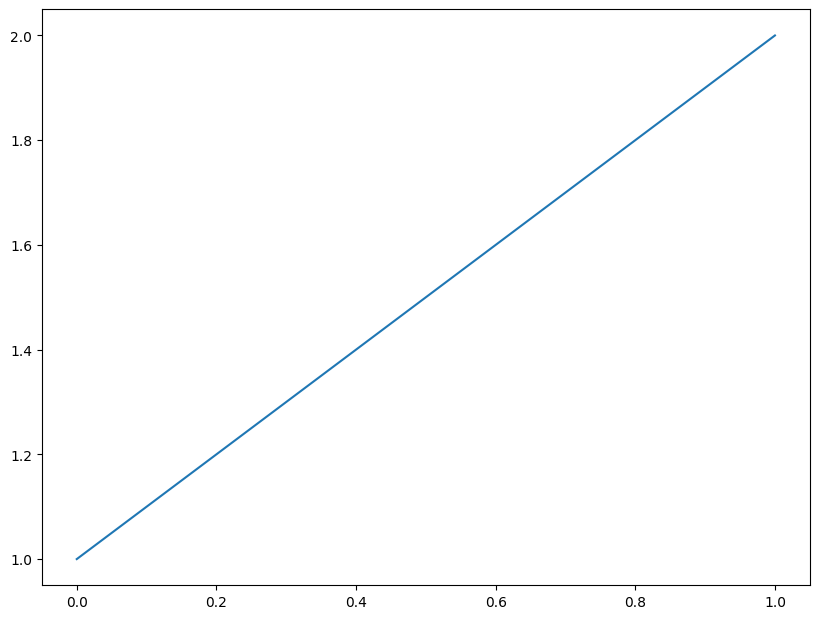

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [104]:
fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 1.2, 1.2])  # [left, bottom, width, height] in figure coordinates
#left, bottom (relative/prozent zu einem bestimmten Punkt ; Prozent zum "default Größe")
# Unterschied ist das du hierbei die volle Kontrolle hast wie du es platzierst
plt.plot([1,2])
plt.show()
plt.gcf()

In [ ]:
#For add_axes — it's relative to the figure, so:For add_axes — it's relative to the figure, so:
mpl.rcParams['figure.figsize']      # (6.4, 4.8) default width/height in inches
mpl.rcParams['figure.dpi']          # 100 — so 640x480 pixels default

#that's what the [left, bottom, width, height] coords are relative to — the figure canvas in 0-1 figure coordinates.

#For add_subplot — it's about the grid spacing:
mpl.rcParams['figure.subplot.left']    # 0.125 — left edge of subplots
mpl.rcParams['figure.subplot.right']   # 0.9   — right edge
mpl.rcParams['figure.subplot.bottom']  # 0.11  — bottom edge
mpl.rcParams['figure.subplot.top']     # 0.88  — top edge
mpl.rcParams['figure.subplot.wspace']  # 0.2   — width space between subplots
mpl.rcParams['figure.subplot.hspace']  # 0.2   — height space between subplots
#these are what matplotlib uses to auto-position subplots within the figure — the numbers add_axes makes you define manually.

In [186]:
#plt.gcf() #getCurrentFigure()

#It prints because Figure has a __repr__ method defined — that's the Python special method that controls what an object looks like when printed/displayed.
#Specifically:
#fig.__repr__()
#plt.gcf() #getCurrentFigure()

print(fig.get_size_inches())          # [6.4, 4.8]
print(fig.dpi)                        # 100
#print(fig.get_size_inches()) * fig.dpi  # [640, 480]
print(len(fig.axes))                  # 0

# returns: '<Figure size 640x480 with 0 Axes>'

[6.4 4.8]
100.0
1


In [148]:
#and this is true for all Artists — they all have __repr__ defined:
ax.__repr__()      # <Axes: >
#line.__repr__()    # <matplotlib.lines.Line2D object at

"<Axes: title={'center': 'A Simple Scatterplot'}, xlabel='X', ylabel='Y'>"

## .plot

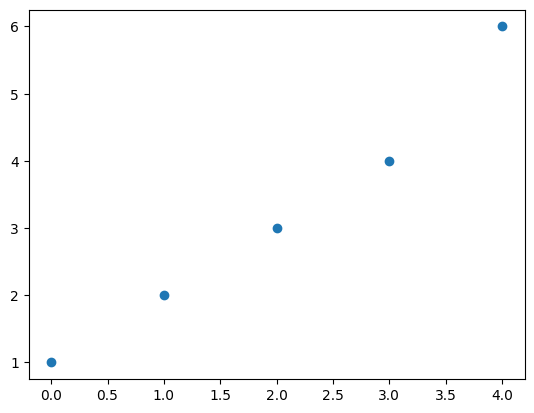

In [ ]:
# Let's add some data
y=[1,2,3,4,6]
#impliziert: 
# x=[0,1,2,3,4]
plt.plot(y, 'o')

#f(x)=x Wertebereich von 1-5
#indizes in Python beginnen mit 0 (meistens), und die gehen bis len(y)-1

In [ ]:
#Every object in Python has __repr__ yes — it's defined on the base object class that everything inherits from.

#there are two:
#__repr__    # unambiguous, for developers — shown in REPL/Jupyter
#__str__     # readable, for users — used by print()
#print() calls __str__ first, falls back to __repr__ if __str__ isn't defined.
#Jupyter just calls __repr__ directly when you evaluate an expression in a cell.

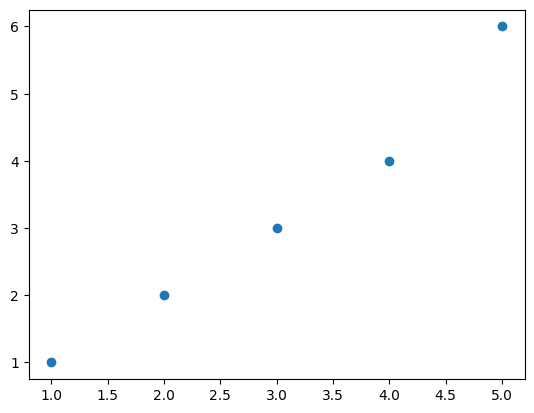

In [107]:
# Create some data
x: list[int] = [1, 2, 3, 4, 5] #0 ... len(y)-1
y: list[int]=[1,2,3,4,6] 
#genau das selbe

# With a semi-colon and now a y value
plt.plot(x, y, 'o');

Figure   1 ── * Axes
Axes     1 ── * Line2D
Axes     1 ── * Patch
Axes     1 ── * Text
Axes     1 ── * Collection

**Navigation — Kind kennt Elternteil**

```python
fig.axes           # Figure  → alle Axes      [ax1, ax2, ...]
ax.get_figure()    # Axes    → Figure

ax.lines           # Axes    → alle Line2D    [line1, ...]
ax.patches         # Axes    → alle Patches   [rect1, ...]
ax.texts           # Axes    → alle Texts     [txt1, ...]
ax.collections     # Axes    → alle Collections (scatter...)

line.axes          # Line2D  → Axes
line.axes.figure   # Line2D  → Figure (über Axes)
```

**Regel**

> jedes Artist-Kind kennt seinen Elternteil  
> kein Artist kann ohne Elternteil existieren — Axes braucht Figure, Line2D braucht Axes

Let's understand figure and axes in little more detail.

Suppose I want to draw our two sets of points (green rounds and blue stars) in two separate plots side-by-side instead of the same plot.

You can do that by creating two separate subplots, or Axes, using `plt.subplots(1, 2)`: this means to creates 1 row with 2 subplots. The command returns two objects:

1. the figure
1. the axes (subplots) inside the figure

![](https://www.machinelearningplus.com/wp-content/uploads/2019/01/99_matplotlib_structure-1.png)

Previously, I called `plt.plot()` to draw the points. Since there was only one axes by default, it drew the points on that axes itself.

But now, since you want the points drawn on different subplots (axes), you have to call the plot function **on the respective axes**.

# Two interfaces for plotting


### MATLAB-like - Zustandsautomat - Zeile für Zeile - Schritt für Schritt

At the top of the matplotlib hierarchy is the "state-machine environment" which is provided by the `matplotlib.pyplot` module. This is also called the **MATLAB-like interface**.

In the examples above, we used this kind of interface. At this level, most of the plotting related elements (lines, images, text, etc.) are handled by the `pyplot` module.

This interface is usually the easiest way to get started with plotting using matplotlib. It is designed to be compatible with [MATLAB](https://it.mathworks.com/products/matlab.html)'s plotting functions, so it is easier to get started with if you are familiar with MATLAB.

It also has a minumum of coding overhead for simple plots.

### Object-oriented

The next level down in the matplotlib hierarchy is the object-oriented (OO) interface.

The main idea with OO programming is to have objects that one can apply functions and actions on, and no object or program states should be global (such as the MATLAB-like interface). The real advantage of this approach becomes apparent when more than one figure is created, or when a figure contains more than one subplot - more about that later.

At this level, the user creates figures with `pyplot`, and through those figures, one or more "axes" objects can be created. These axes objects are then used for most plotting actions.

We use now the OO interface: instead of creating a new global figure instance we store a reference to the newly created figure instance in the `fig` variable, and from it we create a new axis instance using the `add_axes` method:

In [ ]:
axes = fig.add_axes([0.1, 0.1, 0.8, 0.8]) # left, bottom, width, height (range 0-1)

Then, we add a plot to the `axes` object, and customize x-y axis labels and plot title:

Unfortunately, inside Jupter notebooks the plots are reset after evaluating each cell, so we have to put all of the above commands in the same cell to see the result!

### OO vs Matplot

A potentially confusing feature of Matplotlib is that it has two coding interfaces:

* Matlab-like syntax (state-based)
* Object-oriented (OO) syntax (more powerful).

This is partly the reason why matplotlib doesn't have one consistent way of achieving the same given output, making it a bit difficult to understand for newcomers.

So far we have seen both interfaces in action, with a bit more focus on the OO syntax, which is more intuitive and pythonic to work with.

However, since the original purpose of matplotlib was to recreate the plotting facilities of Matlab in Python, the Matlab-like syntax is retained and still works.

The Matlab syntax is state-based, or "stateful".
That means that `plt` keeps track of what the current axes is. So whatever you draw with `plt.{anything}` will be reflected only on the **current** subplot.

In practice, the main difference between the two interfaces is:

* Matlab - all plotting is done using `plt` methods
* OO - all plotting is done using the respective axes methods.

So, the general procedure for the Matlab interface is:

* You manually create one subplot at a time (using `plt.subplot()` or `plt.add_subplot()`) and
* immediately call `plt.plot()` or `plt.{anything}` to modify that specific subplot (axes).

Whatever method you call using `plt` will be drawn in the current axes.

# Foundation: fig 1^<->^* axes 


**Die Hierarchie:**

```
Figure (die gesamte Zeichenfläche)
  └── Axes (der Plotbereich mit x/y-Achsen)
       ├── x-Achse
       ├── y-Achse
       └── Plot-Elemente (Linien, Punkte, etc.)
```

**Wichtig zu verstehen:**

- **Figure** = Das gesamte Fenster/Bild (wie ein Blatt Papier)
- **Axes** = Der eigentliche Plot-Bereich (wie ein Koordinatensystem auf dem Papier)
- Eine Figure kann mehrere Axes enthalten (Subplots)
- Axes ist NICHT die Achse (axis), sondern der gesamte Plot-Bereich!

### Figure

Everything in matplotlib lives within a `Figure` object.

The figure keeps track of all the child Axes, a group of special "Artists" (titles, figure legends, etc), nested subfigures, and the canvas.

A figure can have any number of Axes (at least one, to be useful).

| Attribut | Returns |
|----------|---------|
| `.axes` | `[Axes, ...]` |
| `.texts` | `[Text, ...]` |
| `.patches` | `[Patch, ...]` |
| `.lines` | `[Line2D, ...]` |
| `.images` | `[AxesImage, ...]` |
| `.legends` | `[Legend, ...]` |
| **Property** | **Returns** |
| `facecolor` | color |
| `edgecolor` | color |
| `figwidth` / `figheight` | float (inches) |
| `dpi` | float |
| `frameon` | bool |
| `suptitle` | → Text |

You can think of the figure object as a canvas that holds all the subplots and other plot elements inside it.

In [179]:
print([k for k in vars(fig).keys() if not k.startswith('_')])

for name, obj in [("fig", fig)]:
    print(f"\n=== {name} ===")
    plt.setp(obj)

print(f"\nFigure Größe: {fig.get_size_inches()} inches")
print(f"Axes Position: {ax.get_position()}")

['stale_callback', 'figure', 'clipbox', 'artists', 'lines', 'patches', 'texts', 'images', 'legends', 'subfigs', 'suppressComposite', 'bbox_inches', 'dpi_scale_trans', 'bbox', 'figbbox', 'transFigure', 'transSubfigure', 'patch', 'canvas', 'subplotpars', 'number']

=== fig ===
  agg_filter: a filter function, which takes a (m, n, 3) float array and a dpi value, and returns a (m, n, 3) array and two offsets from the bottom left corner of the image
  alpha: scalar or None
  animated: bool
  canvas: FigureCanvas
  clip_box: `~matplotlib.transforms.BboxBase` or None
  clip_on: bool
  clip_path: Patch or (Path, Transform) or None
  constrained_layout: unknown
  constrained_layout_pads: unknown
  dpi: float
  edgecolor: :mpltype:`color`
  facecolor: :mpltype:`color`
  figheight: float
  figure: `~matplotlib.figure.Figure`
  figwidth: float
  frameon: bool
  gid: str
  in_layout: bool
  label: object
  layout_engine: {'constrained', 'compressed', 'tight', 'none', `.LayoutEngine`, None}
  linewi

**OO Way todo it**

https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html

### .add_subplots

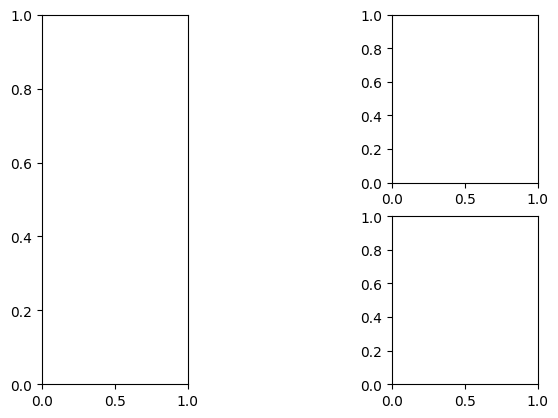

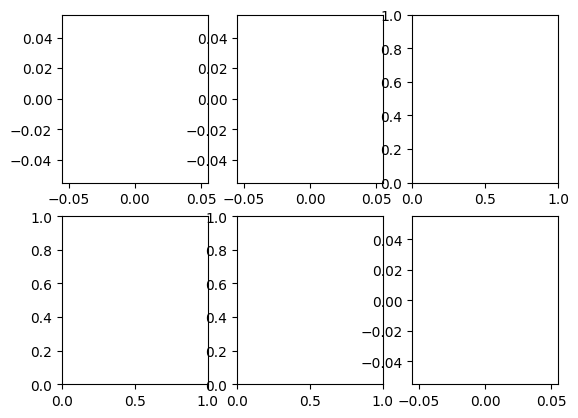

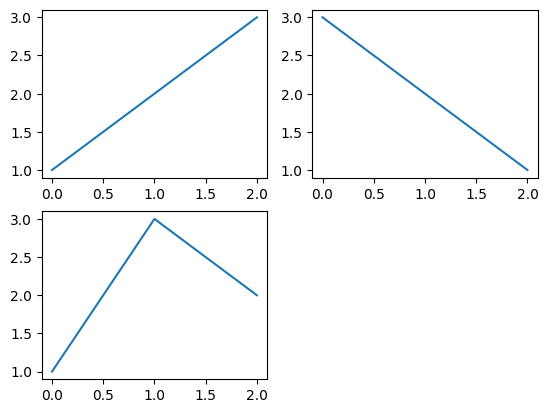

In [151]:
# Creating a plot with the OO verison, confusing way first; 
# #Ihr werdet sowas vielleicht sehen, aber es ist 
# äquivalent zu fig, ax = plt.subplots() und obrigem

from typing import Any

fig = plt.figure()

# add_subplot(nrows, ncols, index)
#
# nrows = wie viele ZEILEN im grid
# ncols = wie viele SPALTEN im grid
# index = position, zählt durch wie lesen: →, dann nächste zeile
#
# ACHTUNG: jeder ax definiert sein EIGENES grid relativ zur ganzen figure!
#
# ax1: grid (1,3) → 1 zeile, 3 spalten
#  [ 1 ][ 2 ][ 3 ]
#   ↑
#   ax1 = position 1 → linkes drittel, VOLLE höhe (weil nur 1 zeile)
#
# ax2 + ax3: grid (2,3) → 2 zeilen, 3 spalten
#  [ 1 ][ 2 ][ 3 ]
#  [ 4 ][ 5 ][ 6 ]
#          ↑     ↑
#          ax2=3  ax3=6 → beide in spalte 3, ax2 oben, ax3 unten
#
# ergebnis:
# ┌──────────┬──────┬──────┐
# │          │      │  ax2 │
# │   ax1    ├──────┼──────┤
# │          │      │  ax3 │
# └──────────┴──────┴──────┘

ax1: Any = fig.add_subplot(1, 3, 1)  # 1 Zeile,  3 Spalten, Position 1 → links, volle Höhe
ax2: Any = fig.add_subplot(2, 3, 3)  # 2 Zeilen, 3 Spalten, Position 3 → oben rechts
ax3: Any = fig.add_subplot(2, 3, 6)  # 2 Zeilen, 3 Spalten, Position 6 → unten rechts

plt.show()

# ---

# äquivalent aber kürzer — gibt numpy array von Axes zurück
fig, axes = plt.subplots(2, 3)  # 2 Zeilen, 3 Spalten

axes[0, 0].plot()  # Zeile 0, Spalte 0
axes[0, 1].plot()  # Zeile 0, Spalte 1
axes[1, 2].plot()  # Zeile 1, Spalte 2

plt.show()

fig: Any = plt.figure()

ax1: Any = fig.add_subplot(2, 2, 1)  # oben links
ax2: Any = fig.add_subplot(2, 2, 2)  # oben rechts
ax3: Any = fig.add_subplot(2, 2, 3)  # unten links
# 4 bleibt leer — einfach nicht hinzufügen

ax1.plot([1,2,3])
ax2.plot([3,2,1])
ax3.plot([1,3,2])

plt.show()

### .add_axes 

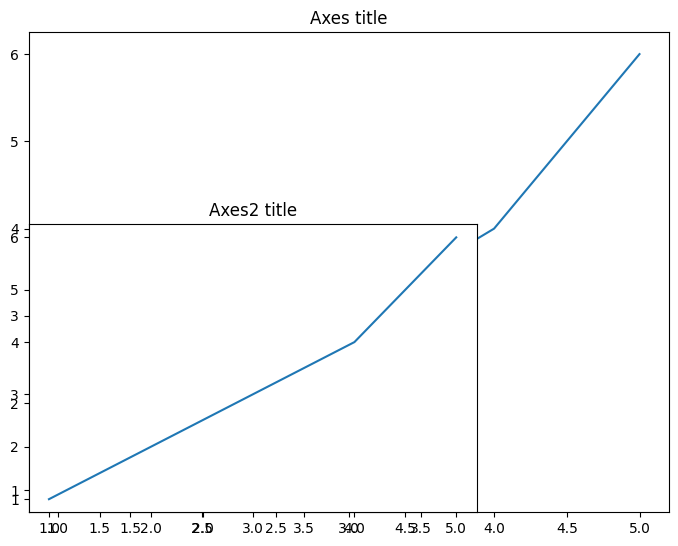

In [109]:
# Confusing #2 - besser als #1 - das hilft aber um charts später zu überlappen 
fig = plt.figure()


ax = fig.add_axes([1,1    ,1,1])
ax.plot(x, y)
ax.set_title("Axes title")

                        
ax2 = fig.add_axes([1,1    ,0.7,0.6])
 # 4 indizes: (Richtung es platziert wird) : x, y
ax2.plot(x, y)
ax2.set_title("Axes2 title")

plt.show()

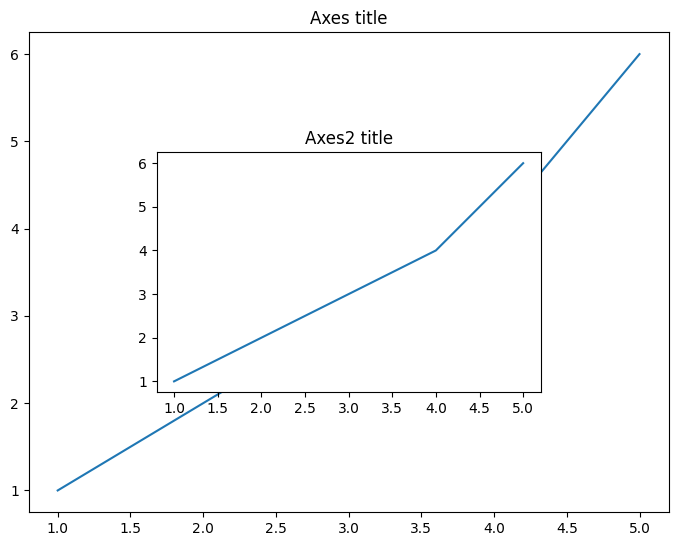

In [110]:
# Confusing #2 - besser als #1 - das hilft aber um charts später zu überlappen 
fig = plt.figure()

ax = fig.add_axes([0.8,1,         1,1])
ax.plot(x, y)
ax.set_title("Axes title")

                              #Größe der Chart zu tun
ax2 = fig.add_axes([1, 1.25,     0.6, 0.5]) # aufeinander
 # 4 indizes: (Richtung es platziert wird) : x, y,        width, height
ax2.plot(x, y)
ax2.set_title("Axes2 title")

plt.show()

Although a little bit more code is involved, the advantage is that we now have full control of where the plot axes are placed, and we can easily add more than one axis to the figure:

In [ ]:
fig = plt.figure()

axes1 = fig.add_axes([0.1, 0.1, 0.8, 0.8]) # main axes
axes2 = fig.add_axes([0.2, 0.5, 0.3, 0.3]) # inset axes

# main figure
axes1.plot(x, y)
axes1.set_xlabel('x')
axes1.set_ylabel('y')
axes1.set_title('y = f(x)')

# inset
axes2.plot(y, x)
axes2.set_xlabel('y')
axes2.set_ylabel('x')
axes2.set_title('x = f(y)');

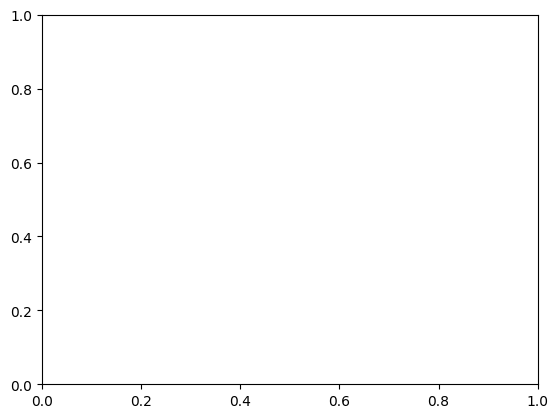

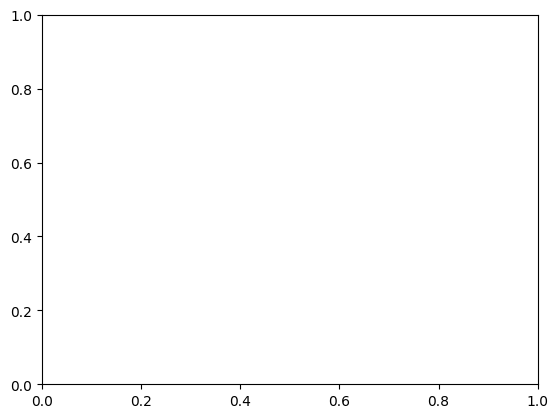

In [157]:
# ── 3 Wege eine Figure zu erstellen ──────────────────────────────────────────

# 1. pyplot — nur figure, noch keine axes
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)  # axes muss man selbst hinzufügen

# 2. pyplot — figure + axes auf einmal (Standard, 95% der Fälle)
fig, ax = plt.subplots()

# 3. pure OO — kein pyplot, kein globaler state
#    wird benutzt in web/GUI apps, nicht in Jupyter
from matplotlib.figure import Figure
fig = Figure()
ax = fig.add_subplot(1, 1, 1)

# ─────────────────────────────────────────────────────────────────────────────
# alle drei geben dasselbe: ein Figure objekt mit einem Axes objekt
# der unterschied ist nur wer den globalen state (plt.gcf / plt.gca) verwaltet
#
#  plt.figure()   →  figure wird in pyplot globalem state registriert
#  plt.subplots() →  figure wird in pyplot globalem state registriert
#  Figure()       →  kein pyplot, kein globaler state — du bist allein verantwortlich

--------------
### .subplots - Häufigste Weg um Axes/Charts zu definieren

https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html

Die Axes werden als Tupeln gegeben (wenn 2,2 ist es ähnlich zu einer Matrize)
![](https://matplotlib.org/stable/_images/sphx_glr_arranging_axes_002_2_00x.png)

mit GridSpec ist es ähnlich (https://matplotlib.org/stable/users/explain/axes/arranging_axes.html); am besten man ordnet jedem ax{0-3} eine Variable zu

![](https://matplotlib.org/stable/_images/sphx_glr_arranging_axes_010_2_00x.png)


If we don't care about specifying where the plot axes are placed in the figure canvas, then we can use one of the many axis layout managers in matplotlib. My favorite is `subplots`, which can be used like this:

Text(0.5, 0.98, 'Figure title')

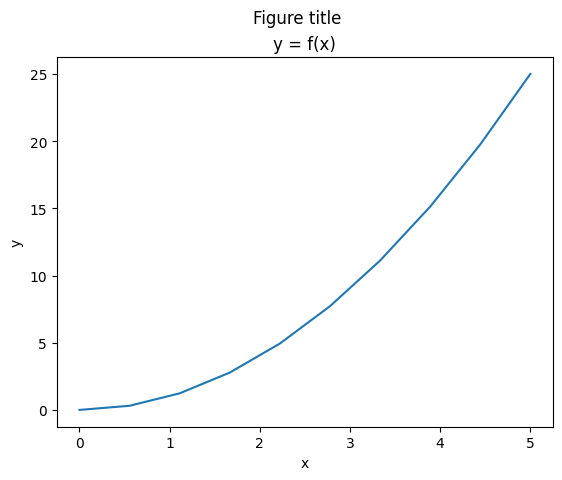

In [153]:
fig, ax = plt.subplots()

ax.plot(x, y)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('y = f(x)') # this is the axis title
fig.suptitle("Figure title") # this is the figure title

Axes(0.125,0.11;0.775x0.77)


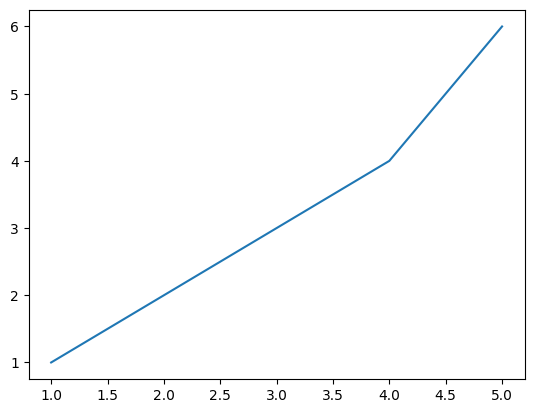

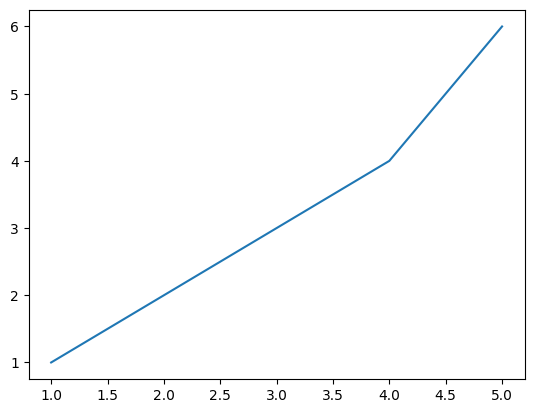

In [111]:
# Easier and more robust going forward (what we're going to use) # Standard
fig, ax = plt.subplots(1,1) #plot = figure ; charts = axes
#ax = fit.add_subplot(1,1,1), nicht gemacht
ax.plot(x, y);
print(ax)

# How to draw 2 scatteplots in different panels
fig, ax2 = plt.subplots()
ax2.plot(x, y);

In [ ]:
fig = plt.figure()  # an empty figure with no axes
axes = fig.add_axes([0.1, 0.1, 0.9, 0.9]) # left, bottom, width, height (range 0-1)

axes.plot(x, y)
axes.set_xlabel('x')
axes.set_ylabel('y')
axes.set_title('Quadratic function')

## .plot - Format/Colors/Lines to Simple scatterplot

We have already seen what `plt.plot()` creates if we you call it on an arbitrary sequence of numbers:


remember and watch out that most things here are now not in OO and use the stateful interface, implicitly managing the fig and ax

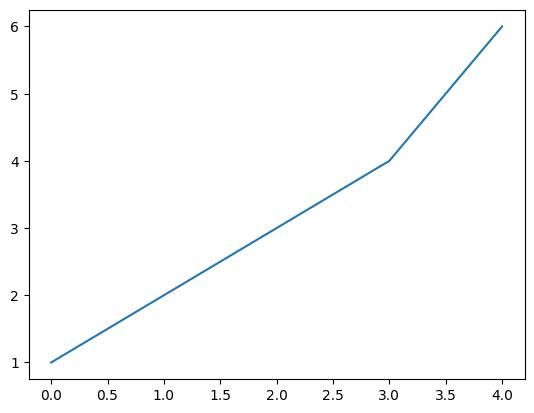

In [112]:
plt.plot(y);

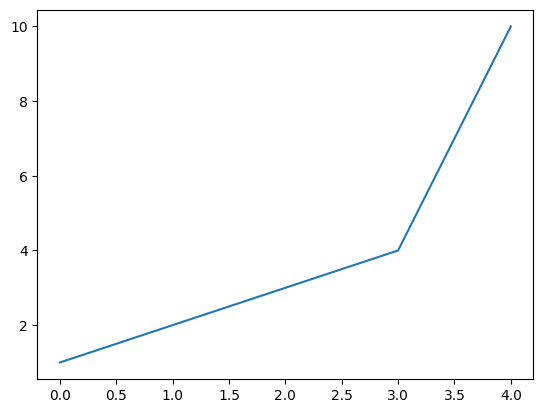

In [113]:
plt.plot([1, 2, 3, 4, 10]);

Matplotlib draws a **line chart** automatically, assuming the values of the X-axis start from zero, going up to as many items in the data.

Notice the line `matplotlib.lines.Line2D` in the above code output?

That's because Matplotlib returns the plot object itself besides drawing the plot.

If you only want to see the plot (e.g. in a non-interactive script), add `plt.show()` at the end and execute all the lines in one shot.

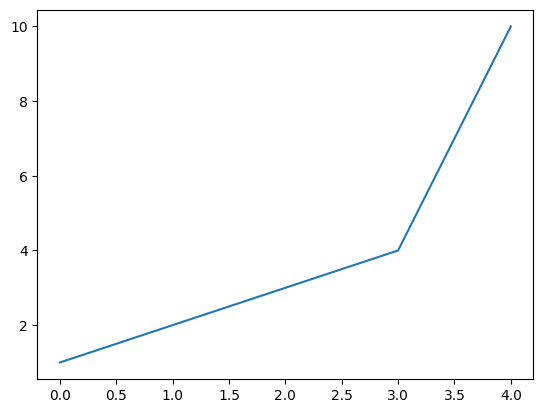

In [114]:
plt.plot([1, 2, 3, 4, 10])
plt.show()

Another possibility is to end the `plt.plot()` command with a semicolon:

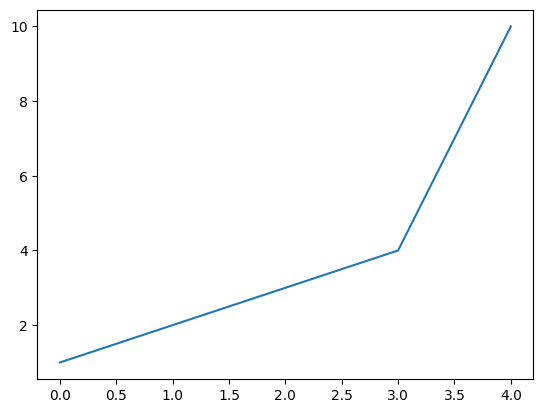

In [115]:
plt.plot([1, 2, 3, 4, 10]);

So, this is not a scatterplot yet, but a line chart. How to draw a real scatterplot?

Let's first focus a bit more about what arguments `plt.plot()` expects.

The three basic arguments are: `plt.plot(x, y, format)` (in this specific order!)

The `format` is a string representing a shorthand combination of `[marker][line][color]`.

Each of them is optional: if not provided, the value from the style cycle is used. Exception: if `line` is given, but no `marker`, the data will be a line without markers.

Commonly used markers are:

- `'.'` (point)
- `'o'` (circle)
- `'*'` (star)
- `'D'` (diamond)

Line styles are:

- `'-'` (solid)
- `'--'` (dashed)
- `'-.'` (dash-dot)
- `':'` (dotted)

Colors are single-letter abbreviations of color names, such as:

- `'b'` (blue)
- `'g'` (green)
- `'r'` (red)
- `'k'` (black)

**Example:** The format `'o-g'` has 3 characters standing for: *green circles with solid line*.
By omitting the `line` part, you will be left with green circles (`‘og’`).

Note that:

1. `format` is not necessarily a 3-character string, since some `line` styles may take up 2 characters (e.g. `'--'`, `'-.'`).
2. you can provide the combination in any order (e.g. `[color][marker][line]`), but the parsing may be ambiguous.

Few commonly used short hand format examples are:

- `'*--r'` : red stars with dashed lines
- `'s:k'` : black squares with dotted line ('k' = black)
- `'D-.b'` : blue diamonds with dash-dot line

For a complete list of colors, markers and linestyles, check out the `help(plt.plot)` command (also [online](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html)).

Let's draw a scatterplot with green dots:

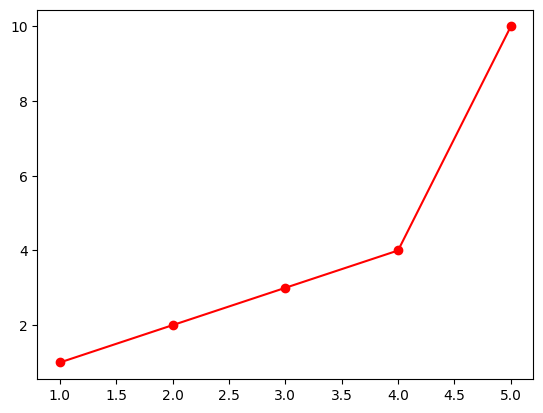

In [116]:
# 'og' stands for green circles
plt.plot([1, 2, 3, 4, 5], [1, 2, 3, 4, 10], 'o-r')
plt.show()

Now how to plot another set of 5 points of different color in the same figure?

Simply call `plt.plot()` again: it will add those point to the same picture.

You might wonder, why it does not draw these points in a new panel altogether? I will come to that in the next section.

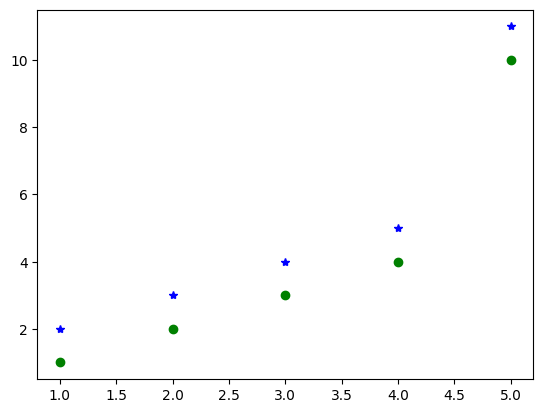

In [117]:
# Draw two sets of points
xx = np.array([1, 2, 3, 4, 5])
yy = np.array([1, 2, 3, 4, 10])
plt.plot(xx, yy, "og")  # green dots
plt.plot(xx, yy+1, "*b")  # blue stars
plt.show()

Looks good. Now let’s add the basic plot features: Title, Legend, X and Y axis labels.

The `plt` object has corresponding methods to add each of these.

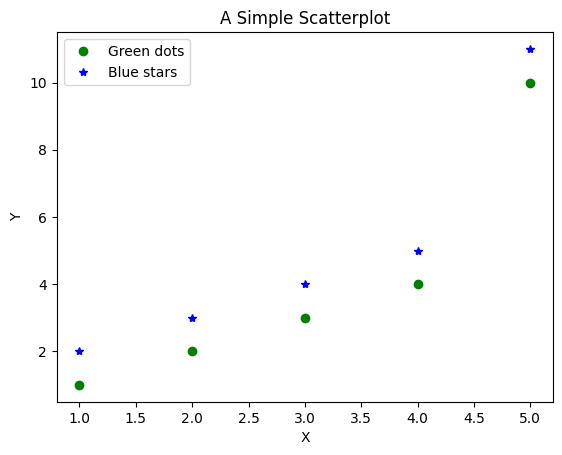

In [118]:
plt.plot(xx, yy, "og", label="Green dots") # we attach a label to be used by the legend
plt.plot(xx, yy+1, "*b", label="Blue stars")

plt.title("A Simple Scatterplot")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend(loc="best")  # legend text comes from the plot's label parameter
plt.show()

# other choices for loc are: 'upper right', 'lower right', 'center', 'right', 'center right' (similarly for left)

How to increase the size of the figure?

The easy way to do it is by setting the `figsize` inside `plt.figure()` method. We also set the x-y axis limits.

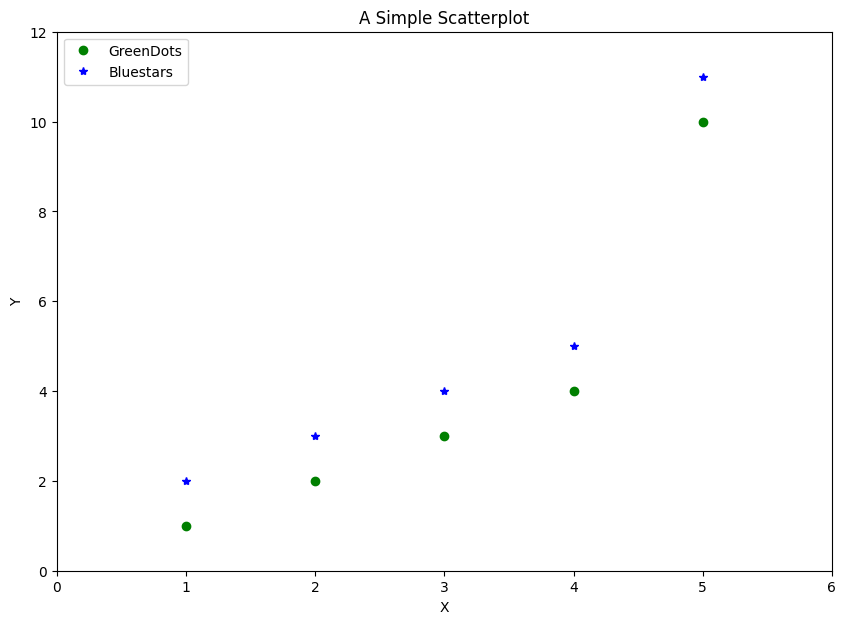

In [119]:
xx = np.array([1, 2, 3, 4, 5])
yy = np.array([1, 2, 3, 4, 10])
plt.figure(figsize=(10, 7))  # (width, height) # durch das Modul deklariert
#plt.add_axes()

plt.plot(xx, yy, "og", label="GreenDots")  # green dots
plt.plot(xx, yy+1, "*b", label="Bluestars")  # blue stars

plt.xlim(0, 6) # x axis limits
#ax.set_xlim(0, 6) # x axis limits; Gegenüberstellung

plt.ylim(0, 12) # y axis limits

plt.title("A Simple Scatterplot")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend(loc="best")
plt.show()

In [ ]:
fig, ax = plt.subplots()

x = np.linspace(0, 5, 10)

ax.plot(x, x+1, color="red", alpha=0.5) # half-transparant red
ax.plot(x, x+2, color="#1155dd") # bluish color
ax.plot(x, x+3, color="#15cc55") # greenish color
plt.show()

## Reflect/Recap: Using the OO Interface

We can write the above example using the OO interface:

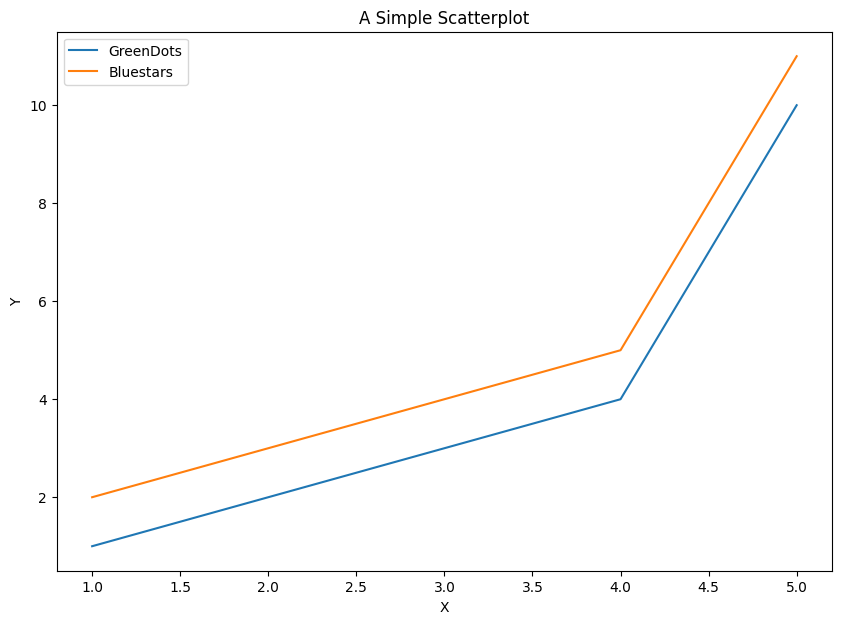

In [120]:
fig, ax = plt.subplots(1,1,figsize=(10, 7))  # (width, height); Durch das OO API-Interface

ax.plot(xx, yy, label="GreenDots")  # green dots
ax.plot(xx, yy+1, label="Bluestars")  # blue stars

#plt.xlim(0,6)
#plt.ylim(0,12)
#ax.set_xlim(0, 6) # x axis limits
#ax.set_ylim(0, 12) # y axis limits

ax.set_title("A Simple Scatterplot")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.legend()
plt.show()

AttributeError: Line2D.set() got an unexpected keyword argument 'linmarker'

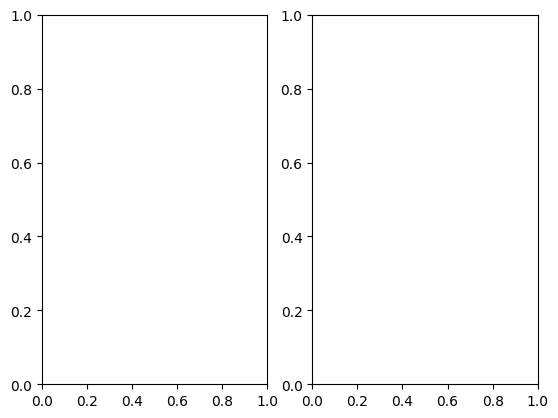

In [121]:
# Create Figure and Subplots, capturing them in separate variables
x = np.linspace(0, 5, 10)
y = x ** 2

fig, axes = plt.subplots(1, 2)

ax1 = axes[0]
ax2 = axes[1]

# Plot
ax1.plot(x, y, linmarker='o')
ax2.plot(x, y, '-o')

plt.show()

The above code seems quite repetitive and can be further optimized:

In [ ]:
fig, axes = plt.subplots(1, 2)

for ax in axes:
    ax.plot(x, y, 'o')

plt.show()

Let's add titles and x-y labels:

In [ ]:
fig, axes = plt.subplots(1, 2)

for ax in axes:
    ax.plot(x, y, 'o')
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("Scatterplot")

plt.show()

Quite good, but figure axes and labels overlap: we fix this with the `fig.tight_layout` method, which automatically adjusts the positions of the axes on the figure canvas so that there is no overlapping content:

In [ ]:
fig, axes = plt.subplots(1, 2)

for ax in axes:
    ax.plot(x, y, 'o')
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("Scatterplot")

fig.tight_layout()
plt.show()

NameError: name 'plt' is not defined

Better, but we notice that the y-axis labels of the right-hand panel are redundant: in the following example, we create two Axes sharing the y axis.

In [ ]:
fig, axes = plt.subplots(1, 2, sharey=True)

for ax in axes:
    ax.plot(x, y, 'o')
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("Scatterplot")

fig.tight_layout()
plt.show()

Thats sounds like a lot of functions to learn! It's actually quite easy to remember them.

The `ax1` and `ax2` objects, like `plt`, have equivalent `set_title`, `set_xlabel` and `set_ylabel` functions. In fact, `plt.title()` actually calls the current axes `set_title()` to do the job.

* `plt.xlabel()` → `ax.set_xlabel()`
* `plt.ylabel()` → `ax.set_ylabel()`
* `plt.xlim()` → `ax.set_xlim()`
* `plt.ylim()` → `ax.set_ylim()`
* `plt.title()` → `ax.set_title()`

Alternately, to save keystrokes, you can set multiple things in one go using the `ax.set()`:

In [ ]:
fig, axes = plt.subplots(1, 2, sharey=True)

for ax in axes:
    ax.plot(x, y, 'o')
    ax.set(title="Scatterplot", xlabel="x", ylabel="y",
           xlim=(0, 6), ylim=(0, 30))

fig.tight_layout()
plt.show()

## Figure size, aspect ratio and DPI

Matplotlib allows the aspect ratio, DPI and figure size to be specified when the `Figure` object is created, using the `figsize` and `dpi` keyword arguments. `figsize` is a tuple of the width and height of the figure in inches, and `dpi` is the dots-per-inch (pixel per inch). To create an 800x400 pixel, 100 dots-per-inch figure, we can do:

In [ ]:
fig = plt.figure(figsize=(8, 4), dpi=100)

The same arguments can also be passed to layout managers, such as the `subplots` function:

## Saving figures

To save a figure to a file we can use the `savefig` method in the `Figure` class:

In [ ]:
fig.savefig("filename.png", dpi=200, format="png")

In this case, the image format is inferred from the filename extension. Available formats include PNG, JPG, EPS, SVG, PDF.

You can also specify the DPI and explicitly set an output format: note that, if you do specify a format, then the literal filename is used, regardless of its extension (it's up to you to check its consistency with the format).

# Compatible data types

Matplotlib can deal with NumPy arrays (as just shown), base Python lists, and Pandas Series and Dataframes.

In [ ]:
xdata = [0, 1, 2, 3, 4, 5]
ydata = [0, 2, 4, 9, 16, 25]
plt.plot(ydata)

In [ ]:
plt.plot(np.array(ydata))

In [ ]:
plt.plot(pd.Series(ydata))

In [ ]:
df = pd.DataFrame({"x": xdata, "y": ydata})
df.head()

In [ ]:
plt.plot(df) # each df's columns is plotted as a separate line and df index is the x-axis values

In [ ]:
plt.plot(df["y"])

In [ ]:
plt.plot(df.index, df["y"])

#  Axes

A figure can have one or more subplots inside it called Axes, arranged in rows and columns. Every figure has at least one Axes. Don't confuse Axes with X and Y axis: they are different!

Figure
├── axes: [Axes, ...]
│     ├── lines, patches, collections, texts, images
│     ├── xaxis / yaxis  → ticks, labels, spine
│     └── legend_

The Axes objects, such as `ax1` and `ax2` above, are what you think of as 'a plot'. It is the region of the image with the data space. A given figure can contain many Axes, but a given Axes object can only be in one Figure. The **Axes** contains two (or three in the case of 3D) **Axis** objects (be aware of the difference between Axes and Axis!!) which take care of the data limits (the data limits can also be controlled via `set_xlim()` and `set_ylim()` Axes methods).

### Axes
| Attribute | Returns |
|----------|---------|
| `.lines` | `[Line2D, ...]` |
| `.patches` | `[Patch, ...]` |
| `.collections` | `[PathCollection, ...]` |
| `.texts` | `[Text, ...]` |
| `.images` | `[AxesImage, ...]` |
| `.xaxis` / `.yaxis` | XAxis / YAxis → Text |
| **Property** | **Returns** |
| `facecolor` | color |
| `xlim` / `ylim` | (float, float) |
| `xscale` / `yscale` | str |
| `xlabel` / `ylabel` | → Text |
| `title` | → Text |
| `xticks` / `yticks` | `[float, ...]` |
| `xticklabels` / `yticklabels` | `[Text, ...]` |
| `frame_on` | bool |
| `aspect` | str / float |

Each Axes has:

1. a title (set via `set_title()`);
1. a x-label (set via `set_xlabel()`);
1. a y-label (set via `set_ylabel()`).

The Axes class and its member functions are the primary entry point to working with the object-oriented programming (OOP) interface.

**Axis**

These are the number-line-like objects. They take care of setting the graph limits and generating the ticks (the marks on the axis) and ticklabels (strings labeling the ticks). The location of the ticks is determined by a Locator object and the ticklabel strings are formatted by a Formatter. The combination of the correct Locator and Formatter gives very fine control over the tick locations and labels.

 **Artist (specific)**

Basically everything you can see on the figure is an artist (even the Figure, Axes, and Axis objects). This includes Text objects, Line2D objects, collection objects, Patch objects ... (you get the idea). When the figure is rendered, all of the artists are drawn to the canvas. Most Artists are tied to an Axes; such an Artist cannot be shared by multiple Axes, or moved from one to another.

---

**Artist: Parts of a figure**
![](https://matplotlib.org/stable/_images/anatomy.png)


=== ax ===
  adjustable: {'box', 'datalim'}
  agg_filter: a filter function, which takes a (m, n, 3) float array and a dpi value, and returns a (m, n, 3) array and two offsets from the bottom left corner of the image
  alpha: scalar or None
  anchor: (float, float) or {'C', 'SW', 'S', 'SE', 'E', 'NE', ...}
  animated: bool
  aspect: {'auto', 'equal'} or float
  autoscale_on: bool
  autoscalex_on: unknown
  autoscaley_on: unknown
  axes_locator: Callable[[Axes, Renderer], Bbox]
  axisbelow: bool or 'line'
  box_aspect: float or None
  clip_box: `~matplotlib.transforms.BboxBase` or None
  clip_on: bool
  clip_path: Patch or (Path, Transform) or None
  facecolor or fc: :mpltype:`color`
  figure: `~matplotlib.figure.Figure`
  forward_navigation_events: bool or "auto"
  frame_on: bool
  gid: str
  in_layout: bool
  label: object
  mouseover: bool
  navigate: bool
  navigate_mode: unknown
  path_effects: list of `.AbstractPathEffect`
  picker: None or bool or float or callable
  position: [

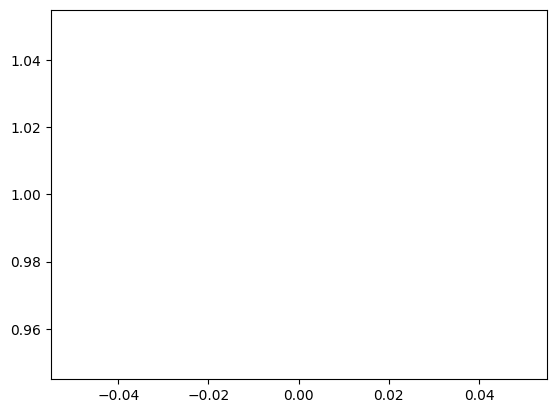

In [184]:
fig, ax = plt.subplots()
line, = ax.plot([1])
# See only the "artist container" attributes##

for name, obj in [("ax", ax), ("line", line)]:
    print(f"\n=== {name} ===")
    plt.setp(obj)

In [ ]:
plt.figure(figsize=(8, 4), dpi=100)

# left hand subplot
plt.subplot(1, 2, 1) # (nRows, nColumns, axes number to plot)
plt.plot(x, y, "og")
plt.title("Scatterplot (green dots)")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(0, 6)
plt.ylim(0, 30)

# right hand subplot
plt.subplot(1, 2, 2)
plt.plot(x, y, "*b")
plt.title("Scatterplot (blue stars)")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(0, 6)
plt.ylim(0, 30)

plt.show()

Let’s breakdown the above piece of code.

In `plt.subplot(1,2,1)`, the first two values (1,2) specify the number of rows (1) and columns (2), and the third value (1) specifies the position of the current subplot. The subsequent `plt` functions will always draw on this current subplot.

You can get a reference to the current (subplot) axes with `plt.gca()` ("get current axis") and the current figure with `plt.gcf()` ("get current figure"). Likewise, `plt.cla()` and `plt.clf()` will clear the current axes and figure respectively.

This stateful interface may be quick and convenient for simpler plots. However, we realize it can lead to problems: for example, once the second panel is created, how can we add something back to the first?

The OO interface might look a but confusing because it has a mix of both `ax` and `plt` commands. However, there is a significant advantage with **the OO approach**, as it **provides more clear control over customization**.

Since `plt.subplots` returns all the axes as separate objects, you can avoid writing repetitive code by looping through the axes, like we did in one of the examples above.

Always remember: `plt.plot()` or `plt.{anything}` will always act on the plot in the *current* axes, whereas `ax.{anything}` will modify the plot inside that specific `ax`.

In the following example, we'll draw multiple plots using for-loops with OO syntax: the target is to have a figure with 4 panels arranged in a 2x2 matrix. The panels will share both X and Y axis.

In [ ]:
np.random.seed(100)

# create Figure and Subplots
fig, axes = plt.subplots(2, 2, figsize=(8, 4), dpi=100,
                         sharex=True, sharey=True)

# define the colors and markers to use
colors = {0:'g', 1:'b', 2:'r', 3:'y'}
markers = {0:'o', 1:'x', 2:'*', 3:'p'}

# plot each axes
for i, ax in enumerate(axes.ravel()): # I use ravel() to obtain a 1D array from a 2x2 matrix
    # generate random data
    xvals = sorted(np.random.randint(0, 10, 10))
    yvals = sorted(np.random.randint(0, 10, 10))

    ax.plot(xvals, yvals, marker=markers[i], color=colors[i])
    ax.set_title(f'Axes: {i}')
    ax.yaxis.set_ticks_position('none')

plt.suptitle('Four Subplots in One Figure', fontsize=16)
plt.tight_layout()
plt.show()

Things to notice:

1. you can specify marker type, color, and line through dedicated arguments within `plot()`, instead of using the `fmt` string
1. Y axis ticks were switched off with `ax.yaxis.set_ticks_position("none")`

Another advantage of the OO interface is the possibility to set a dynamic title for each subplot.

You can actually get a reference to any specific element of the plot and use its methods to manipulate it.

`plt.suptitle()` adds a main title at figure level.
(`plt.title()` would have done the same for the current subplot)

So far you have learned the core essence creating and manipulating a plot using `matplotlib`.
Next, let’s see how to modify other components of the plot.

## .scatter

In addition to the regular `plot` method, there are a number of other functions for generating different kind of plots: for example, the `scatter` method.

In [ ]:
fig, ax = plt.subplots()
ax.scatter(x, x**2)
plt.show()

How is this different from a scatterplot drawn with `plot`?

The difference is `plt.plot()` does not provide options to change the color and size of point dynamically (based on another array).
`plt.scatter()` allows you to do that.

By varying the size and color of points, you can create (for example) nice looking bubble plots.

Another convenience is that you can directly use a Pandas dataframe to set the x and y values, provided you specify the source dataframe in the `data` argument.

You can also set the color 'c' and size 's' of the points from one of the dataframe columns itself.

In [ ]:
import pandas as pd

midwest = pd.read_csv(
    "https://raw.githubusercontent.com/selva86/datasets/master/midwest_filter.csv"
)
midwest.head()

In [ ]:
# Scatterplot with varying size and color of points
fig = plt.figure(figsize=(8, 4))

plt.scatter("area", "poptotal", data=midwest, s="dot_size", c="popdensity")
plt.title("Bubble plot")
plt.xlabel("Area")
plt.ylabel("Poptotal")
plt.colorbar()
plt.show()

## .legend

Legends for curves in a figure can be added in two ways. One method is to use the `legend` method of the axis object and pass a list/tuple of legend texts for the previously defined curves:

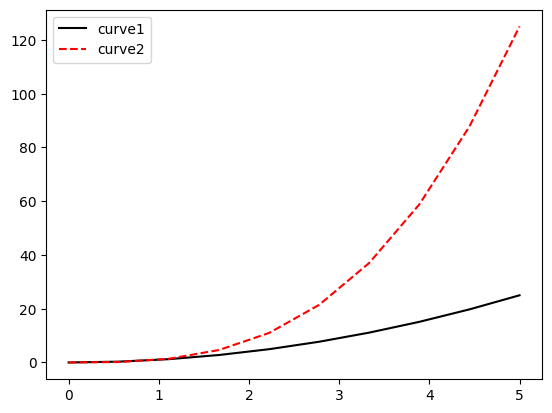

In [164]:
x = np.linspace(0, 5, 10)

fig = plt.figure()
ax = fig.add_subplot()
ax.plot(x, x**2, color="black")
ax.plot(x, x**3, color="red", linestyle="dashed")
ax.legend(["curve1", "curve2"])
plt.show()



This method is somewhat prone to errors and unflexible if curves are added to or removed from the figure (resulting in a wrongly labelled curve).

A better method is to use the `label="label text"` keyword argument when plots or other objects are added to the figure, and then using the `legend` method without arguments to add the legend to the figure:

In [ ]:
fig, ax = plt.subplots()

ax.plot(x, x**2, color="black", label="curve1")
ax.plot(x, x**3, color="red", linestyle="dashed", label="curve2")
ax.legend()
plt.show()

The advantage with this method is that if curves are added or removed from the figure, the legend is automatically updated accordingly.

The `legend` function takes an optional keyword argument `loc` that can be used to specify where in the figure the legend is to be drawn. The allowed values of `loc` are numerical codes for the various places the legend can be drawn. See http://matplotlib.org/users/legend_guide.html#legend-location for details. Some of the most common `loc` values are:

```
ax.legend(loc=0) # (default) let matplotlib decide the optimal location
ax.legend(loc=1) # upper right corner
ax.legend(loc=2) # upper left corner
ax.legend(loc=3) # lower left corner
ax.legend(loc=4) # lower right corner
# .. many more options are available
```

The following figure shows how to use the figure title, axis labels and legends described above:

In [ ]:
fig, ax = plt.subplots()

ax.plot(x, x**2, label="y = x**2")
ax.plot(x, x**3, label="y = x**3")
ax.legend(loc=2) # upper left corner
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('title')

plt.show()

## Formatting: LaTeX, rcParams, plot styles


Matplotlib has great support for LaTeX. All we need to do is to use dollar signs to encapsulate LaTeX equations in any text (legend, title, label, etc.). For example, `"$y=x^3$"`.

But here we can run into a slightly subtle problem with LaTeX code and Python text strings. In LaTeX, we frequently use the backslash in commands, for example `\alpha` to produce the symbol $\alpha$. But the backslash already has a meaning in Python strings (the escape code character). To avoid Python messing up our latex code, we need to use "raw" text strings. Raw text strings are prepended with an '`r`', like `r"\alpha"` or `r'\alpha'` instead of `"\alpha"` or `'\alpha'`.

In [ ]:
fig, ax = plt.subplots()

ax.plot(x, x**2, label=r"$y = \alpha^2$")
ax.plot(x, x**3, label=r"$y = \alpha^3$")
ax.legend(loc=2) # upper left corner
ax.set_xlabel(r'$\alpha$', fontsize=18)
ax.set_ylabel(r'$y$', fontsize=18)
ax.set_title('title')

plt.show()

The look and feel of various components of a matplotlib plot can be set globally using *rcParams*.

The complete list of rcParams is very exhaustive: see the [help page](https://matplotlib.org/stable/api/matplotlib_configuration_api.html#matplotlib.rcParams) for the full list and explanation.
You can also view it by typing:

In [ ]:
import matplotlib as mpl
mpl.rc_params()

You can dynamically adjust the params you'd like to change by updating it at runtime.
For example, the below snippet adjusts the font by setting it to ['stix'](https://www.stixfonts.org/), which is a good choice since it looks great on plots.

In [ ]:
mpl.rcParams.update({'font.size': 18,
                     'font.family': 'STIXGeneral',
                     'mathtext.fontset': 'stix'})

In [ ]:
fig, ax = plt.subplots()

ax.plot(x, x**2, label=r"$y = \alpha^2$")
ax.plot(x, x**3, label=r"$y = \alpha^3$")
ax.legend(loc=2) # upper left corner
ax.set_xlabel(r'$\alpha$', fontsize=18)
ax.set_ylabel(r'$y$', fontsize=18)
ax.set_title('title')

plt.show()

After modifying a plot, you can rollback the rcParams to default setting using:

In [ ]:
mpl.rcParams.update(mpl.rcParamsDefault)  # reset to defaults

This looks more convenient than R's way to deal with graphical parameters (`op <- par(mfrow=(2,1); ...; par(op))`)

Matplotlib comes with **pre-built styles** that you can browse by typing:

In [ ]:
plt.style.available

Notice `fivethirtyeight`, and `ggplot`.

`seaborn` is called after another high-level plotting library that is especially useful if your input is in a Pandas dataframe. Note however that the seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn.

Let's play with some of the pre-built styles by creating a function that takes a style name as input and produces a plot with sine and cosine waves.

In [ ]:
# our custom function
def plot_sine_cosine_wave(style="ggplot"):
    mpl.rcParams.update(mpl.rcParamsDefault)
    plt.style.use(style)

    X = np.linspace(0, 2 * np.pi, 100)

    fig, ax = plt.subplots(figsize=(8, 4), dpi=100)
    ax.plot(X, np.sin(X))
    ax.plot(X, np.cos(X))
    ax.set(xlabel="x (radians)", ylabel="y", title=style)
    plt.show()
    mpl.rcParams.update(mpl.rcParamsDefault)

In [ ]:
plot_sine_cosine_wave("fivethirtyeight")

In [ ]:
plot_sine_cosine_wave("ggplot")

In [ ]:
plot_sine_cosine_wave("dark_background")

## .plot() : Colors, line widths, line types

We have already seen that we can define markers, colors, and line types with a `format` string such as `og-.` (green circles with dash-dot line).

You can also set these properties separately using appropriate keywork arguments inside `plot`.
 
 **Colors**

Define colors by their names or RGB hex codes and optionally provide an alpha value using the `color` and `alpha` keyword arguments:

In [ ]:
fig, ax = plt.subplots()

x = np.linspace(0, 5, 10)

ax.plot(x, x+1, color="red", alpha=0.5) # half-transparant red
ax.plot(x, x+2, color="#1155dd") # bluish color
ax.plot(x, x+3, color="#15cc55") # greenish color
plt.show()

Matplotlib also comes with **pre-built colors and palettes**. Type the following in your jupyter/python console to check out the available colors.

In [ ]:
# View Colors
mpl.colors.CSS4_COLORS  # 148 colors

In [ ]:
mpl.colors.XKCD_COLORS  # 949 colors

In [ ]:
mpl.colors.BASE_COLORS  # 8 colors

In [169]:
# View first 10 Palettes
dir(plt.cm)[:10]

['Accent',
 'Accent_r',
 'Blues',
 'Blues_r',
 'BrBG',
 'BrBG_r',
 'BuGn',
 'BuGn_r',
 'BuPu',
 'BuPu_r']

For more information and examples on Matplotlib's color palettes, have a look at the [official documentation](https://matplotlib.org/stable/gallery/color/colormap_reference.html).

## Line and marker styles

To change the line width, we can use the `linewidth` (or `lw`) keyword argument. The line style can be selected using the `linestyle` (or `ls`) keyword arguments:

In [ ]:
fig, ax = plt.subplots(figsize=(12,6))

ax.plot(x, x+1, color="blue", linewidth=0.25)
ax.plot(x, x+2, color="blue", linewidth=0.50)
ax.plot(x, x+3, color="blue", linewidth=1.00)
ax.plot(x, x+4, color="blue", linewidth=2.00)

# possible linestype options ‘-‘, ‘--’, ‘-.’, ‘:’, ‘steps’
ax.plot(x, x+5, color="red", lw=2, linestyle='-')
ax.plot(x, x+6, color="red", lw=2, ls='-.')
ax.plot(x, x+7, color="red", lw=2, ls=':')

# custom dash
line, = ax.plot(x, x+8, color="black", lw=1.50)
line.set_dashes([5, 10, 15, 10]) # format: line length, space length, ...

# possible marker symbols: marker = '+', 'o', '*', 's', ',', '.', '1', '2', '3', '4', ...
ax.plot(x, x+ 9, color="green", lw=2, ls='--', marker='+')
ax.plot(x, x+10, color="green", lw=2, ls='--', marker='o')
ax.plot(x, x+11, color="green", lw=2, ls='--', marker='s')
ax.plot(x, x+12, color="green", lw=2, ls='--', marker='1')

# marker size and color
ax.plot(x, x+13, color="purple", lw=1, ls='-', marker='o', markersize=2)
ax.plot(x, x+14, color="purple", lw=1, ls='-', marker='o', markersize=4)
ax.plot(x, x+15, color="purple", lw=1, ls='-', marker='o', markersize=8, markerfacecolor="red")
ax.plot(x, x+16, color="purple", lw=1, ls='-', marker='s', markersize=8,
        markerfacecolor="yellow", markeredgewidth=2, markeredgecolor="blue")

plt.show()

# Axes 1^<-->^{2...*} Axis appearance**

The appearance of the axes is an important aspect of a figure that we often need to modify to make a publication quality graphics. We need to be able to control where the ticks and labels are placed, modify the font size and possibly the labels used on the axes. In this section we will look at controling those properties in a matplotlib figure.

## .{x.y}lim & .{x,y}bound

The first thing we might want to configure is the ranges of the axes. We can do this using the `set_ylim` and `set_xlim` methods in the axis object, or `axis('tight')` for automatrically getting "tightly fitted" axes ranges:

In [ ]:
fig, ax = plt.subplots()

ax.plot(x, x**2, x, x**3) # note how you can also provide several x-y pairs
ax.set_xlim([2, 5])
ax.set_ylim([0, 60])
ax.set_title("Custom axes range")
plt.show()

In [ ]:
fig, ax = plt.subplots()

ax.plot(x, x**2, x, x**3) # note how you can also provide several x-y pairs
ax.axis("tight")
ax.set_title("Tight axes")
plt.show()

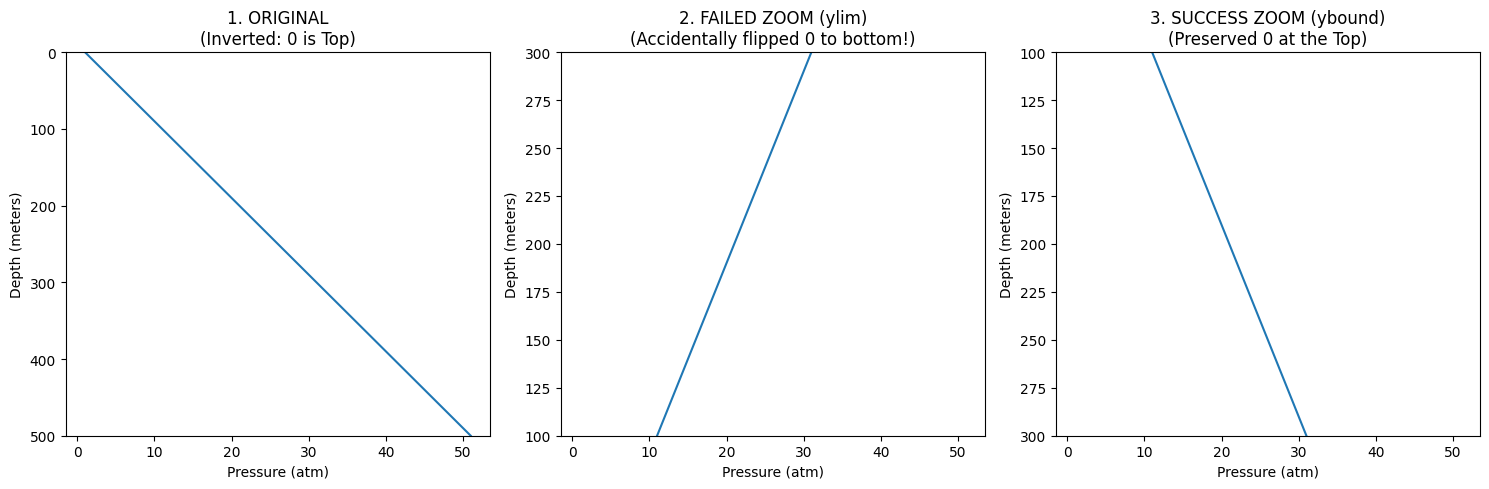

In [168]:
import matplotlib.pyplot as plt

# Create data for a "Depth" plot (e.g., Ocean Pressure)
depth = [0, 100, 200, 300, 400, 500]
pressure = [1, 11, 21, 31, 41, 51]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# --- 1. THE SETUP ---
# We want 0 at the top (Surface) and 500 at the bottom (Deep)
for ax in [ax1, ax2, ax3]:
    ax.plot(pressure, depth)
    ax.set_ylim(500, 0) # INVERTED: High number at bottom
    ax.set_ylabel("Depth (meters)")
    ax.set_xlabel("Pressure (atm)")

ax1.set_title("1. ORIGINAL\n(Inverted: 0 is Top)")

# --- 2. THE "FAILURE" WITH ylim ---
# I want to zoom in on 100m to 300m. 
# But I pass them in 'natural' order (100, 300)...
ax2.set_ylim(100, 300) 
ax2.set_title("2. FAILED ZOOM (ylim)\n(Accidentally flipped 0 to bottom!)")

# --- 3. THE "SUCCESS" WITH ybound ---
# I use the exact same numbers, but with ybound.
ax3.set_ybound(100, 300) 
ax3.set_title("3. SUCCESS ZOOM (ybound)\n(Preserved 0 at the Top)")

plt.tight_layout()
plt.show()

## Logarithmic scale

In [ ]:
fig, axes = plt.subplots(1, 2)

axes[0].plot(x, x**2, x, np.exp(x))
axes[0].set_title("Normal scale")

axes[1].plot(x, x**2, x, np.exp(x))
axes[1].set_yscale("log")
axes[1].set_title("Logarithmic scale (y)")

plt.show()

## Placement of ticks and custom tick labels

We can explicitly determine where we want the axis ticks with `set_xticks` and `set_yticks`, which both take a list of values for where on the axis the ticks are to be placed. We can also use the `set_xticklabels` and `set_yticklabels` methods to provide a list of custom text labels for each tick location:

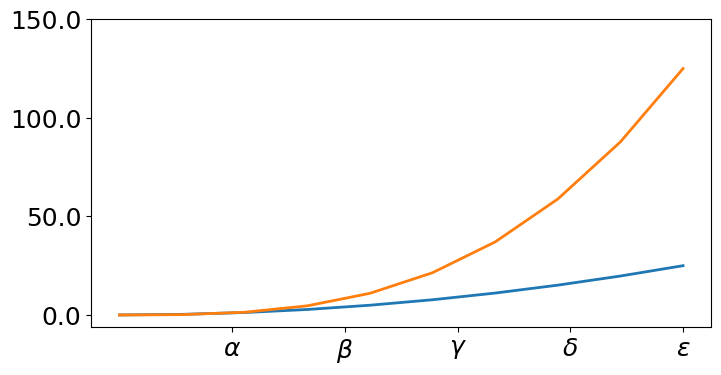

In [182]:
x = np.linspace(0, 5, 10)

xticks = [1, 2, 3, 4, 5]
custom_xticklabels = [r'$\alpha$', r'$\beta$', r'$\gamma$', r'$\delta$', r'$\epsilon$']

yticks = [0, 50, 100, 150]
custom_yticklabels = [f"{y:.1f}" for y in yticks]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, x**2, x, x**3, lw=2)
ax.set_xticks(xticks)
ax.set_xticklabels(custom_xticklabels, fontsize=18)
ax.set_yticks(yticks)
ax.set_yticklabels(custom_yticklabels, fontsize=18)

plt.show()

**Scientific notation**

With large numbers on x or y axis, it is often better use scientific notation: to this end, with an Axes `ax` object we use `ax.xaxis.set_major_formatter(formatter)` (`ax.yaxis.set_major_formatter(formatter)`) with a Formatter object.

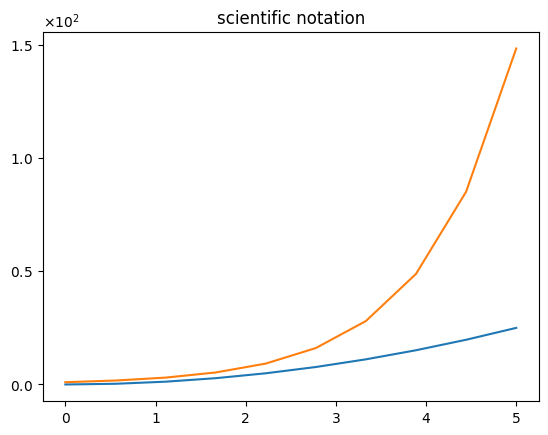

In [183]:
fig, ax = plt.subplots(1, 1)

ax.plot(x, x**2, x, np.exp(x))
ax.set_title("scientific notation")

ax.set_yticks(yticks)

from matplotlib import ticker
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-1,1))
ax.yaxis.set_major_formatter(formatter)

plt.show()

# Credits

Partially abridged from matplotlib.org, Machine Learning Plus, J.R. Johansson (CC-BY 3.0).
Data Visualization Lab Course of UniTrento